#### **FACTIBILIDAD DE LA SOLUCIÓN**

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
from importlib import reload
import copy

import Clases.asignacion as asignacion_module
reload(asignacion_module)
from Clases.asignacion import Asignacion

import Clases.caja as caja_module
reload(caja_module)
from Clases.caja import Caja

import Clases.producto as producto_module
reload(producto_module)
from Clases.producto import Producto

import Clases.solucion as solucion_module
reload(solucion_module)
from Clases.solucion import Solucion

catalogo_productos = pd.read_csv("Datos-finales/catalogo_productos.csv")
especificaciones_cajas = pd.read_csv("Datos-finales/especificaciones_cajas.csv")
operaciones_planta = pd.read_csv("Datos-finales/operaciones_planta.csv")
procurement_cajas = pd.read_csv("Datos-finales/procurement_cajas.csv")

cajas_nuevas = pd.read_csv("Datos-finales/cajas_nuevas.csv")

Guardamos primero los tipos de cajas y los productos en listas de python.

In [55]:
cajas = {
    row["caja_tipo_id"]: Caja(
        caja_id=row["caja_tipo_id"],
        dim_interior_ancho=row["caja_interior_ancho"],
        dim_interior_largo=row["caja_interior_largo"],
        dim_interior_alto=row["caja_interior_alto"]
    )
    for _, row in cajas_nuevas.iterrows()
}

In [56]:
prod_op_merge = catalogo_productos.merge(operaciones_planta, on="codigo_producto")

productos = {
    row["codigo_producto"]: Producto(
        codigo_producto = row['codigo_producto'],
        cantidad_paquetes = row['cantidad_paquetes'],
        peso_paquete = row['peso_neto_paquete'],
        demanda_buenos_aires = row['volumen_producto_planta_buenos_aires'],
        demanda_curitiba = row['volumen_producto_planta_curitiba'],
        demanda_santiago = row['volumen_producto_planta_santiago'],
        demanda_monterrey = row['volumen_producto_planta_monterrey'],
        demanda_bakersfield = row['volumen_producto_planta_bakersfield'],
        dim_producto_ancho = row['dim_producto_ancho'], 
        dim_producto_largo = row['dim_producto_largo'],
        dim_producto_alto = row['dim_producto_alto']
    )
    for _, row in prod_op_merge.iterrows()
}

#### **Factibilidad con grosor = 5mm**

La idea sería ver cuántos tipos de cajas se pueden asignar por producto, considerando las restricciones de dimensión interna, headspace y resistencia a comprensión. Cada chequeo se verifica dentro de la class Asignacion.

Empecemos viendo la factiblidad con un tamaño de grosor de 5mm, importando antes las cajas redimensionadas.

In [57]:
cajas_5mm = cajas.copy()

for caja_id, caja in cajas_5mm.items(): 
    caja.elegir_grosor(5)


In [58]:
cajas_asignables_5mm = {}

for codigo, producto in productos.items():
    cajas_asignables = []
    for caja_id, caja in cajas_5mm.items():
        asignacion = Asignacion(producto, caja)
        if asignacion.es_asignacion_valida() and caja.utilizacion_pallet() >= 0.6:
            cajas_asignables.append(caja_id)
    
    cajas_asignables_5mm[codigo] = cajas_asignables

Veamos en detalle cuántos tipos de cajas son asignables por cada producto.

In [59]:
df_factibilidad_5mm = pd.DataFrame([
    {
        'codigo_producto': codigo,
        'cantidad_cajas_asignables': len(cajas_asign),
    }
    for codigo, cajas_asign in cajas_asignables_5mm.items()
])

df_factibilidad_5mm = df_factibilidad_5mm.sort_values('cantidad_cajas_asignables', ascending=False)
df_factibilidad_5mm

,codigo_producto,cantidad_cajas_asignables
257,BR0255,2227
258,BR0256,2155
353,BR0348,2007
136,BR0136,1952
307,BR0305,1950
...,...,...
217,BR0215,598
221,BR0219,575
232,BR0230,554
168,BR0167,487


Observemos que el espacio de búsqueda se redujo hasta la mitad mínimamente, y como máximo se pueden asignar 117 tipos de cajas a un mismo producto, siendo el caso de BR0241. 

Veamos cómo se distribuye esta cantidad en un gráfico.

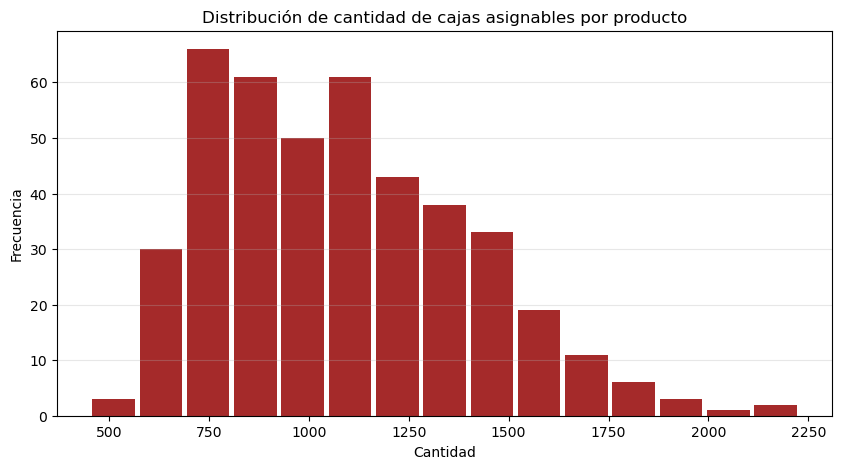

In [60]:
plt.figure(figsize=(10, 5))
plt.hist(df_factibilidad_5mm['cantidad_cajas_asignables'].dropna(), bins=15,
         color='brown', rwidth=0.9)
plt.title('Distribución de cantidad de cajas asignables por producto')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

Podemos notar que la mayoría de productos suelen poder utilizar hasta 60-80 tipos de cajas, aunque hay casos casos que utilizan más de 100. Comparando con la situación original de 204 tipos de cajas, esta reducción nos genera una gran ventaja en la optimización posterior.

Exportemos los resultados a csv:

In [62]:
data = []

for codigo, cajas_asignables in cajas_asignables_5mm.items():
    producto = productos[codigo]
    for caja_id in cajas_asignables:
        caja = cajas[caja_id]
        data.append({
            'codigo_producto': codigo,
            'caja_tipo_id': caja_id
        })

df_exportar = pd.DataFrame(data)
df_exportar.to_csv('Factibilidad/factibilidad3_5mm.csv', index=False)

#### **Factibilidad con grosor = 4.5mm**